Building JSA grid...


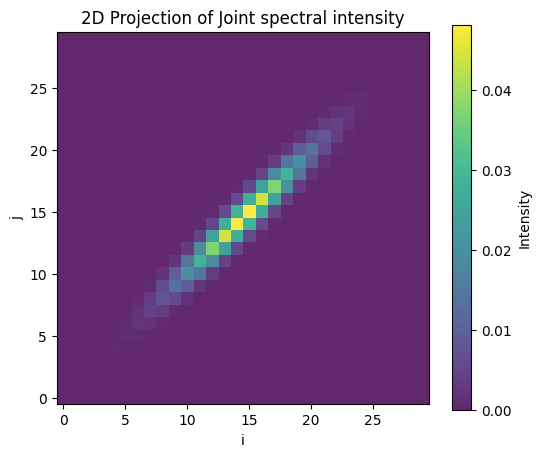

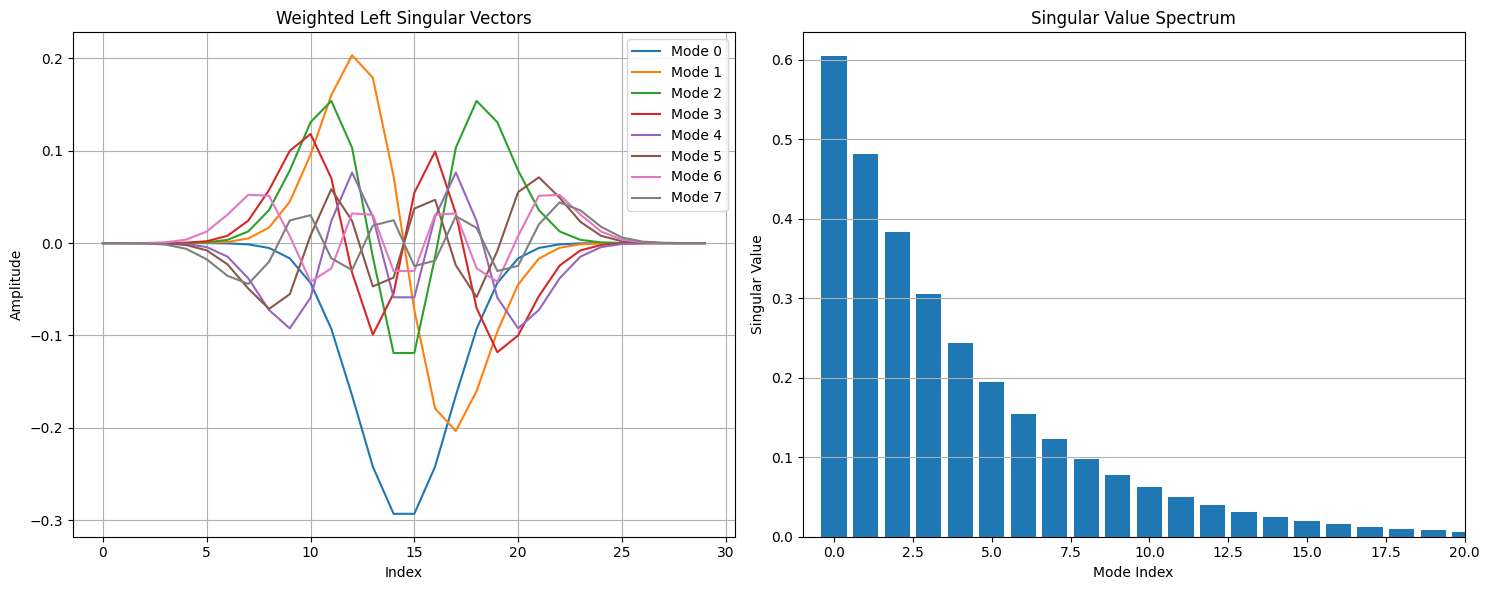

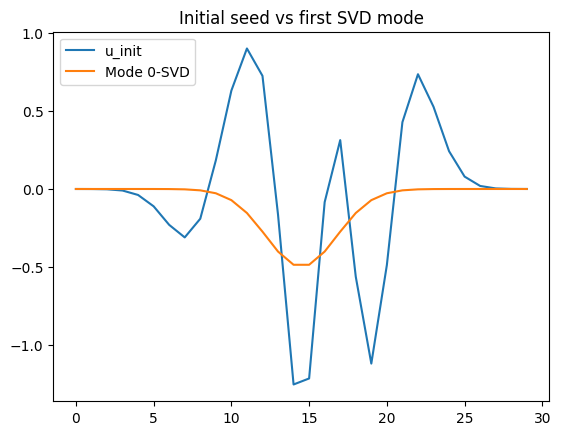


Running trust-region optimization...
basinhopping step 0: f -0.451136
basinhopping step 1: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
found new global minimum on step 1 with function value -0.451136
basinhopping step 2: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
found new global minimum on step 2 with function value -0.451136
basinhopping step 3: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
basinhopping step 4: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
basinhopping step 5: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
basinhopping step 6: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
basinhopping step 7: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
basinhopping step 8: f -0.451136 trial_f -0.451136 accepted True lowest_f -0.451136
found new global minimum on step 8 with function value -0.451136
basinhopping step 9: f -0.451136 trial_f -0.451136 accepted Tr

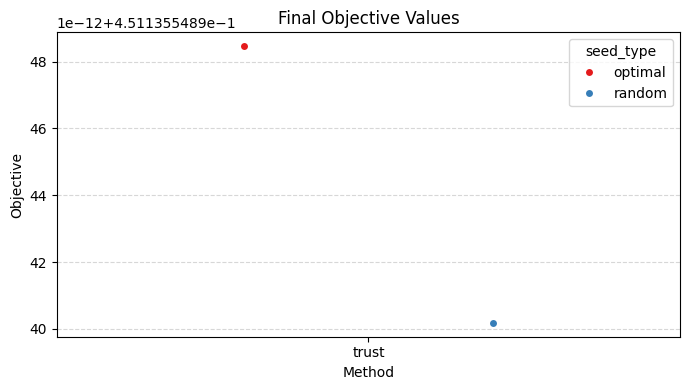

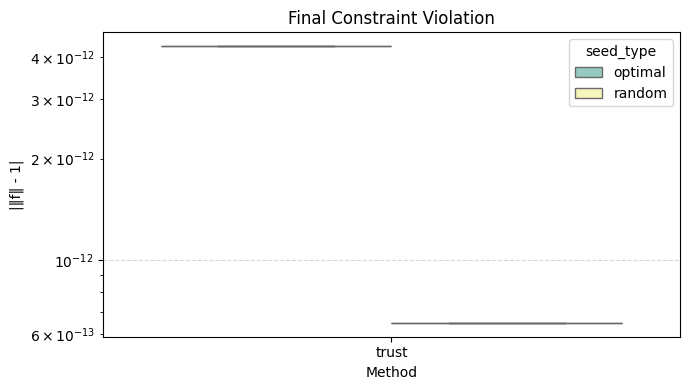


Plotting amplitudes...


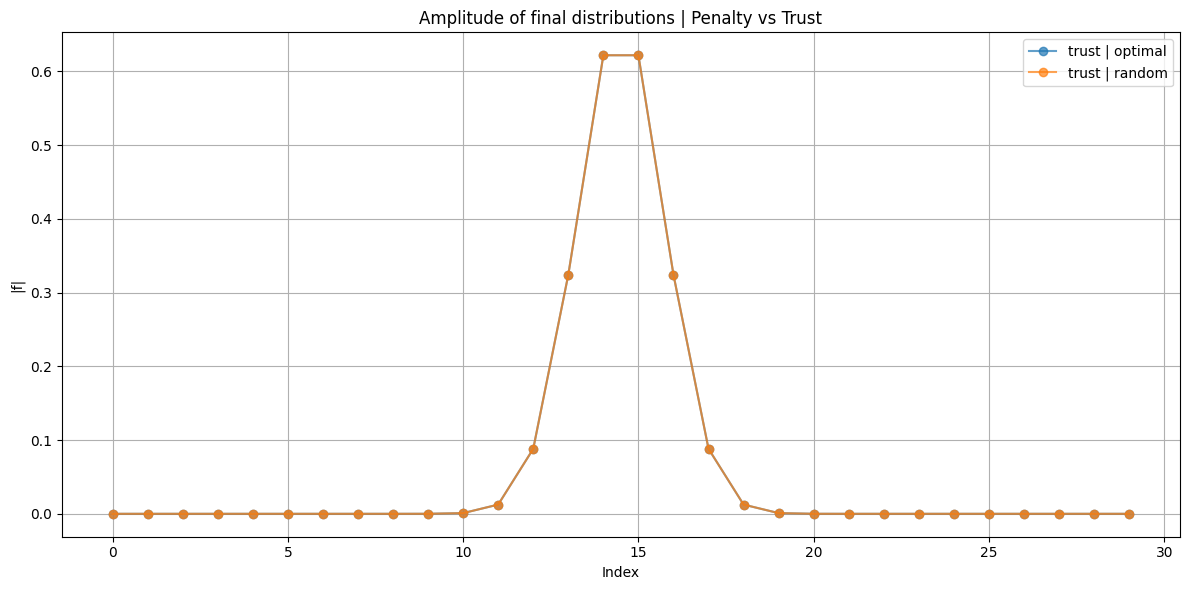


Experiment complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
# jax.config.update('jax_default_device', jax.devices('cpu')[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    run_penalty_only,
    run_trust_only,
    save_results,
    load_results,
    plot_2d_projection,
    plot_modes,
    plot_init_mode,
    plot_all_amplitudes,
    plot_constraint_violation,
    plot_final_objective,
    plot_outer_iterations,
    plot_outer_objective_both_seeds,
)

# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 30  # Number of points in the frequency grid nxnxn
d = 5  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 3  # Limits in x and y ax0is for plotting
rho_value = 0.96  # Correlation coefficient

# filename = f"penalty_results_{d}D_20260303.pkl"

seed_init = 12345
K = 1  # Number of random seeds for optimization runs (for both methods)

bh_kwargs = {"n_iter": 500, "displ": True}

lambda0 = 1e-2
lambda_factor = 2
tol_constraint = 1e-6
max_outer_iters = 40
max_inner_iters = 500

params = {
    "n": n,
    "mean": mean,
    "x_lim": x_lim,
    "rho_value": rho_value,
    "seed_init": seed_init,
    "K": K,
    "bh_kwargs": bh_kwargs,
    "lambda0": lambda0,
    "lambda_factor": lambda_factor,
    "tol_constraint": tol_constraint,
    "max_outer_iters": max_outer_iters,
    "max_inner_iters": max_inner_iters,
}

# ---------------------------------------------------------
# 2. Build JSA grid and initial mode
# ---------------------------------------------------------

print("Building JSA grid...")
jsa = build_jsa_grid(n=n, mean=mean, rho=rho_value, x_lim=x_lim)

# Initial seed (optimal)
_, jsa_data = build_jsa_grid(n, mean, rho_value, x_lim)
jsa_flat = jnp.reshape(jsa_data, (n, n ** (d - 1)))
u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

plot_2d_projection(jsa_data)
plot_modes(u, s, n_modes=8)

nv = 8
u_init = jnp.sum(u[:, :nv] / jnp.linalg.norm(u[:, :nv], axis=0), axis=1)
u_init_normal = u_init / jnp.linalg.norm(u_init)
f_init = jnp.concatenate([u_init_normal, jnp.zeros_like(u_init_normal)])
plot_init_mode(u_init, u[:, 0] / jnp.linalg.norm(u[:, 0]))

# ---------------------------------------------------------
# 3. Generate reproducible random seeds
# ---------------------------------------------------------


def generate_seeds(K, seed_init):
    rng = np.random.default_rng(seed_init)
    return rng.integers(0, 2**32 - 1, size=K)


seeds = generate_seeds(K, seed_init)

# ---------------------------------------------------------
# 4. Run penalty-only (fast)
# ---------------------------------------------------------

# print("\nRunning penalty-only optimization...")
# df_pen = run_penalty_only(
#     f_opt_init=f_init,
#     jsa=jsa_data,
#     seeds=seeds,
#     lambda0=lambda0,
#     lambda_factor=lambda_factor,
#     tol_constraint=tol_constraint,
#     max_outer_iters=max_outer_iters,
#     max_inner_iters=max_inner_iters,
# )


# save_results(df_pen, params, seeds, filename=filename)
# print("Penalty results saved.")

# ---------------------------------------------------------
# 5. Run trust-only (slow, can be done later)
# ---------------------------------------------------------

print("\nRunning trust-region optimization...")
df_trust = run_trust_only(
    f_opt_init=f_init,
    jsa=jsa_data,
    seeds=seeds,
    bh_kwargs=bh_kwargs,
)

save_results(df_trust, params, seeds, filename=f"trust_results_{d}D_20260305.pkl")
print("Trust-region results saved.")

# ---------------------------------------------------------
# 6. Load both and compare
# ---------------------------------------------------------

print("\nLoading saved results...")
# df_pen_loaded, params_loaded, seeds_loaded = load_results(filename)
df_trust_loaded, _, _ = load_results(f"trust_results_{d}D_20260305.pkl")


# ---------------------------------------------------------
# 7. Plots and data
# ---------------------------------------------------------
# df = pd.concat([df_pen_loaded, df_trust_loaded], ignore_index=True)
# df=df_pen_loaded
df = df_trust_loaded

# def outer_converged(row):
#     if row["outer_info"] is None:
#         return None
#     return row["outer_info"][-1]["converged"]

# df["outer_converged"] = df.apply(outer_converged, axis=1)
# print(df[df["method"] == "penalty"][["method", "seed_type", "outer_converged"]])

print(
    df[df["method"] == "trust"][
        ["method", "seed_type", "trust_success", "trust_status", "trust_message"]
    ]
)

# plot_outer_iterations(df)
# plot_outer_objective_both_seeds(df)
plot_final_objective(df)
plot_constraint_violation(df)


# ---------------------------------------------------------
# 9. Plot amplitudes
# ---------------------------------------------------------

print("\nPlotting amplitudes...")
# plot_all_amplitudes(df_pen_loaded)
plot_all_amplitudes(df_trust_loaded)


print("\nExperiment complete.")